In [ ]:
# Import necessary libraries
import tensorflow as tf
import numpy as np
import pathlib
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow import keras
from google.colab import drive
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

#  Mount Google Drive
drive.mount('/content/drive')

# Set the base directory inside Google Drive
new_base_dir = pathlib.Path("/content/drive/MyDrive/Colab Notebooks/cats_vs_dogs_small")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#preprocessing of data(train, validation, test)
from tensorflow.keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=(180, 180),
    batch_size=32)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=(180, 180),
    batch_size=32)

Found 2010 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


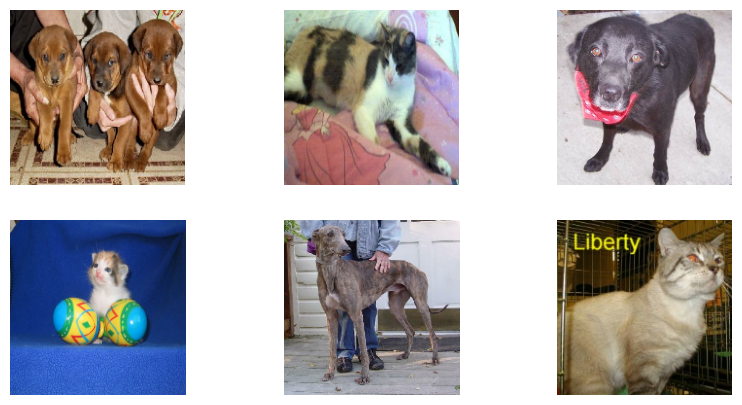

In [ ]:
batch_images, batch_labels = next(iter(train_dataset))
plt.figure(figsize=(10, 5))

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(batch_images[i].numpy().astype("uint8"))
    plt.axis("off")

plt.show()

In [ ]:
#Display the shapes of the data and labels
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break


data batch shape: (32, 180, 180, 3)
labels batch shape: (32,)


1.build a base model from scratch

In [ ]:
inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 178, 178, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 89, 89, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 87, 87, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 43, 43, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 41, 41, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 18, 18, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 9, 9, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 7, 7, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │          12,545 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#training the model
model.compile(loss="binary_crossentropy",
              optimizer="Adam",
              metrics=["accuracy"])

In [12]:
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 380s 6s/step - accuracy: 0.4861 - loss: 0.6981 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step - accuracy: 0.4991 - loss: 0.6925 - val_accuracy: 0.5040 - val_loss: 0.6904
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 215s 3s/step - accuracy: 0.5099 - loss: 0.6885 - val_accuracy: 0.5500 - val_loss: 0.6843
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 257s 3s/step - accuracy: 0.5537 - loss: 0.6796 - val_accuracy: 0.6490 - val_loss: 0.6363
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 259s 3s/step - accuracy: 0.6057 - loss: 0.6599 - val_accuracy: 0.6050 - val_loss: 0.6706
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 263s 3s/step - accuracy: 0.6762 - loss: 0.6131 - val_accuracy: 0.6810 - val_loss: 0.6097
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - accuracy: 0.6914 - loss: 0.5888 - val_accuracy: 0.6340 - val_loss: 0.6589
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.7124 - loss: 0.5473 - val_accuracy: 0.6820 - v

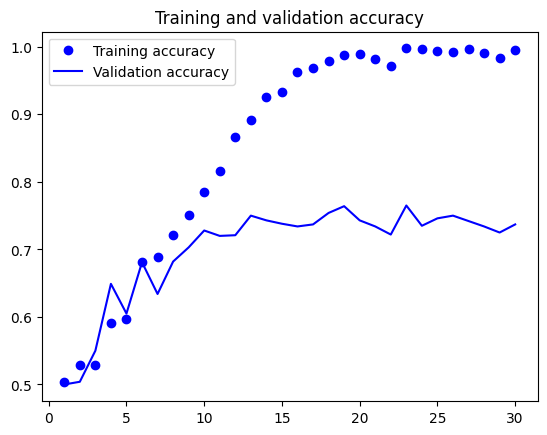

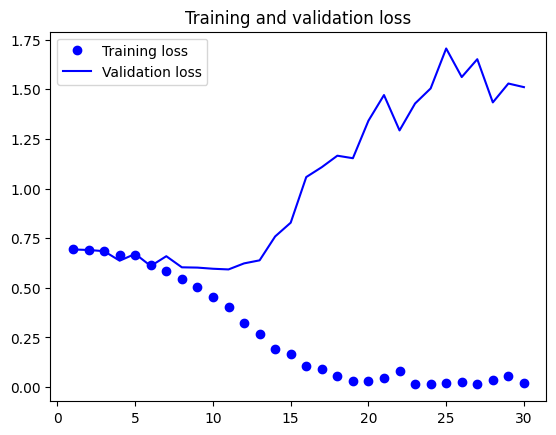

In [13]:
#plot the results during training
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()


In [14]:
#evaluating the model on test data
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 203s 6s/step - accuracy: 0.7043 - loss: 1.8377
Test accuracy: 0.7100


In [15]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

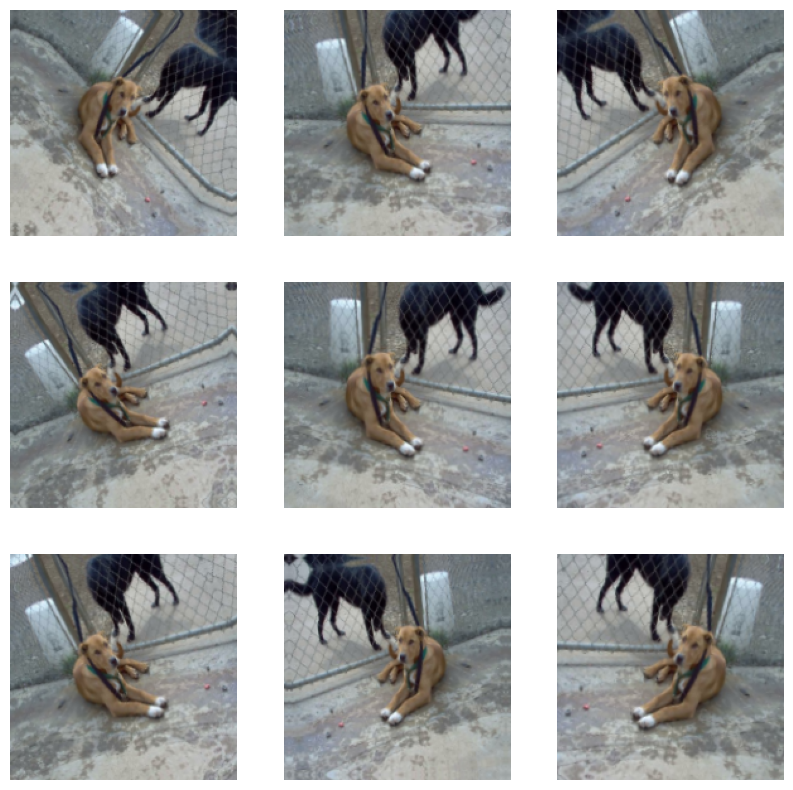

In [16]:
#display augumented tarining images
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")


2. create a new model which includes image augmentation and dropout:

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint

inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_1 (Rescaling)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 178, 178, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 89, 89, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 87, 87, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 43, 43, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 41, 41, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 18, 18, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 9, 9, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 7, 7, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │          12,545 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#comiliing the model
model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

In [19]:
callbacks = ModelCheckpoint(
    filepath="model2.keras",
    save_best_only=True,
    monitor="val_loss"
)

In [21]:
#training the model
Model_2 = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=[callbacks]
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 223s 3s/step - accuracy: 0.5005 - loss: 0.6999 - val_accuracy: 0.5650 - val_loss: 0.6928
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 249s 3s/step - accuracy: 0.4929 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 276s 4s/step - accuracy: 0.4690 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 258s 3s/step - accuracy: 0.5000 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.5205 - loss: 0.6958 - val_accuracy: 0.5620 - val_loss: 0.6837
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 219s 3s/step - accuracy: 0.5410 - loss: 0.6887 - val_accuracy: 0.5870 - val_loss: 0.6736
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 245s 3s/step - accuracy: 0.5864 - loss: 0.6726 - val_accuracy: 0.5710 - val_loss: 0.6693
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step - accuracy: 0.6220 - loss: 0.6543 - val_accuracy: 0.6500 - v

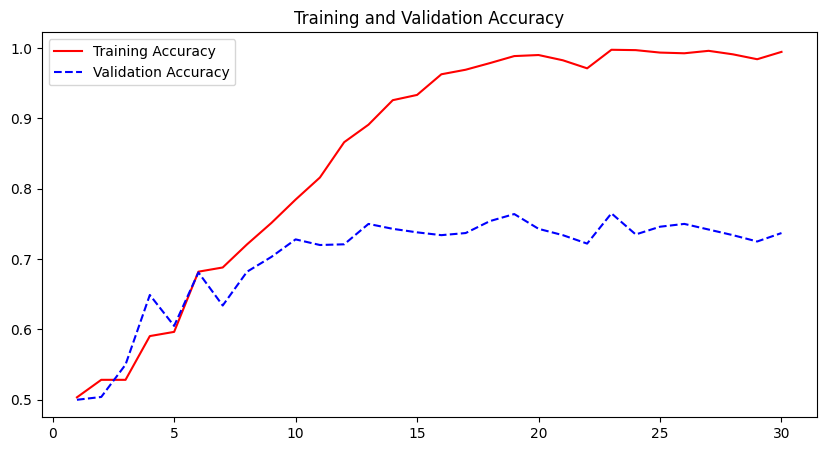

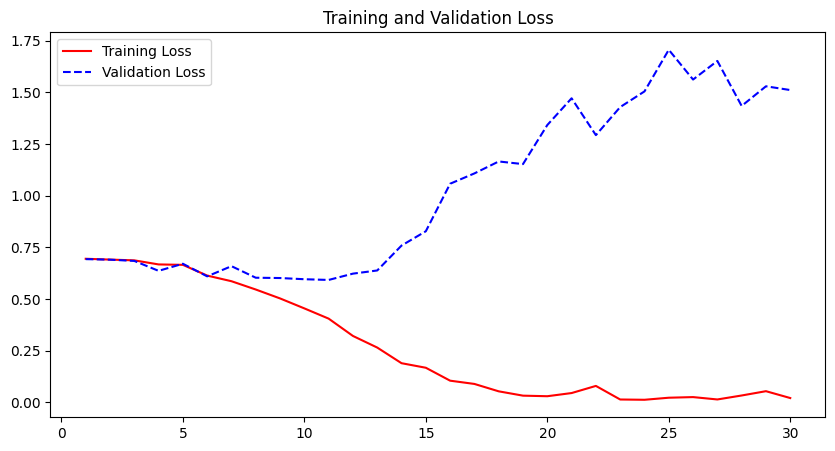

In [22]:
#plot the results
import matplotlib.pyplot as plt

accuracy = Model_2.history["accuracy"]
val_accuracy = Model_2.history["val_accuracy"]
loss = Model_2.history["loss"]
val_loss = Model_2.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, history.history['accuracy'], color="red", label="Training Accuracy")
plt.plot(epochs, history.history['val_accuracy'], color="blue", linestyle="dashed", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()


plt.figure(figsize=(10, 5))
plt.plot(epochs, history.history['loss'], color="red", label="Training Loss")
plt.plot(epochs, history.history['val_loss'], color="blue", linestyle="dashed", label="Validation Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

In [23]:
#evaluating the model
test_model = keras.models.load_model("model2.keras")
Model2_Results = test_model.evaluate(test_dataset)
print(f'Loss: {Model2_Results[0]:.3f}')
print(f'Accuracy: {Model2_Results[1]:.3f}')

32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 837ms/step - accuracy: 0.7543 - loss: 0.4815
Loss: 0.464
Accuracy: 0.774


**3**. model evalution with reducing the sample size

In [24]:
# Image Data Generators for data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # Splitting dataset for validation
)

# Create validation and test generators
validation_generator = data_gen.flow_from_directory(
    new_base_dir / "train",
    target_size=(180, 180),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    new_base_dir / "test",
    target_size=(180, 180),
    batch_size=32,
    class_mode='binary'
)

Found 402 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [25]:


# Create training generator with limited samples
train_generator = data_gen.flow_from_directory(
    new_base_dir / "train",
    target_size=(180, 180),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)



Found 1608 images belonging to 2 classes.


In [26]:
small_sample_size = 500  #we can change this to test different sample sizes
train_gen_samples = min(train_generator.samples, small_sample_size)
train_gen_samples

500

In [27]:
# Build CNN Model from Scratch
model_3 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(180, 180, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
# Compile the model
model_3.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

In [29]:
# Train the model
history_3 = model_3.fit(
    train_generator,
    steps_per_epoch=train_gen_samples // 32,
    epochs=20,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // 32
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 70s 4s/step - accuracy: 0.4947 - loss: 0.7228 - val_accuracy: 0.5547 - val_loss: 0.6923
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 82s 6s/step - accuracy: 0.5384 - loss: 0.6961 - val_accuracy: 0.5130 - val_loss: 0.6911
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 82s 6s/step - accuracy: 0.5620 - loss: 0.6819 - val_accuracy: 0.5365 - val_loss: 0.6895
Epoch 4/20
 6/15 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5449 - loss: 0.6925

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


15/15 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.5305 - loss: 0.6964 - val_accuracy: 0.5234 - val_loss: 0.6869
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step - accuracy: 0.5641 - loss: 0.6673 - val_accuracy: 0.5495 - val_loss: 0.6878
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 81s 6s/step - accuracy: 0.5577 - loss: 0.6859 - val_accuracy: 0.5521 - val_loss: 0.6852
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 81s 6s/step - accuracy: 0.5791 - loss: 0.6768 - val_accuracy: 0.5286 - val_loss: 0.6901
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.5593 - loss: 0.6964 - val_accuracy: 0.5547 - val_loss: 0.6838
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - accuracy: 0.5066 - loss: 0.6865 - val_accuracy: 0.5521 - val_loss: 0.6873
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.6028 - loss: 0.6646 - val_accuracy: 0.5052 - val_loss: 0.6977
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 82s 6s/step - accuracy: 0.4799 - loss: 0.7114 - val_accuracy: 0.5990 - val_loss: 0.6709
E

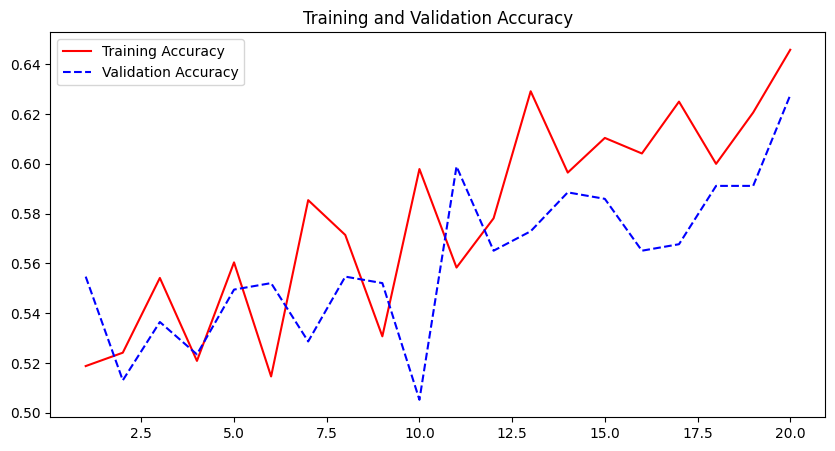

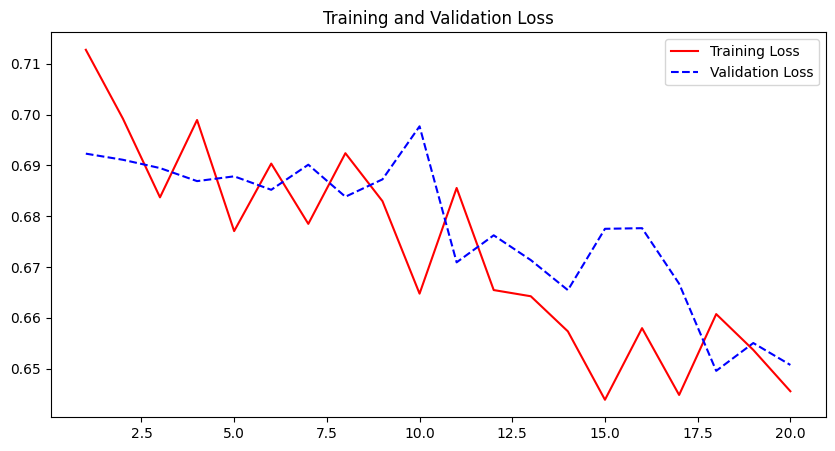

In [36]:
accuracy = history_3.history["accuracy"]
val_accuracy = history_3.history["val_accuracy"]
loss = history_3.history["loss"]
val_loss = Model_2.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, history_3.history['accuracy'], color="red", label="Training Accuracy")
plt.plot(epochs, history_3.history['val_accuracy'], color="blue", linestyle="dashed", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()


plt.figure(figsize=(10, 5))
plt.plot(epochs, history_3.history['loss'], color="red", label="Training Loss")
plt.plot(epochs, history_3.history['val_loss'], color="blue", linestyle="dashed", label="Validation Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

In [41]:
#evaluate the model
test_loss, test_acc = model_3.evaluate(test_generator)
print(f'Test Accuracy for {small_sample_size} samples: {test_acc * 100:.2f}%')


32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 764ms/step - accuracy: 0.6440 - loss: 0.6465
Test Accuracy for 500 samples: 64.20%


4. using a pre trained network, with different sample size and optimization techniques.

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint

#  Mount Google Drive
drive.mount('/content/drive')

# Set the base directory inside Google Drive
new_base_dir = pathlib.Path("/content/drive/MyDrive/Colab Notebooks/cats_vs_dogs_small")

# Image Data Generators for data augmentation
data_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # Splitting dataset for validation
)
# Create validation and test generators
validation_generator = data_gen.flow_from_directory(
    new_base_dir / "train",
    target_size=(180, 180),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    new_base_dir / "test",
    target_size=(180, 180),
    batch_size=32,
    class_mode='binary'
)
# Experiment with different training sample sizes
training_sizes = [750]  # Updated dataset sizes to test
best_acc = 0
best_size = 0
results = {}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 402 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [64]:
for size in training_sizes:
 print(f"\nTraining with {size} samples...")

# Create training generator with limited samples
train_generator = data_gen.flow_from_directory(
    new_base_dir / "train",
    target_size=(180, 180),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
   )
train_gen_samples = min(train_generator.samples, size)


Training with 750 samples...
Found 1608 images belonging to 2 classes.


In [73]:
# Using a Pretrained Model (VGG16)
base_model = VGG16(weights='imagenet',
                   include_top=False,
                   input_shape=(180, 180, 3))
base_model.trainable = False  # Freeze the base model

model_4 = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [74]:
#compiling the model
model_4.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [75]:
# Setting up ModelCheckpoint callback
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='feature_extraction_resnet.keras',
        save_best_only=True,
        monitor='val_loss'
    )
]

In [78]:
# Training the model
history_4 = model_4.fit(
    train_generator,
    steps_per_epoch=train_gen_samples // train_generator.batch_size,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=len(validation_generator)
)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 421s 19s/step - accuracy: 0.8179 - loss: 0.4315 - val_accuracy: 0.8632 - val_loss: 0.3558
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 473s 21s/step - accuracy: 0.7828 - loss: 0.4812 - val_accuracy: 0.8209 - val_loss: 0.3838
Epoch 3/30
 5/23 ━━━━━━━━━━━━━━━━━━━━ 2:43 9s/step - accuracy: 0.8199 - loss: 0.4191 

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


23/23 ━━━━━━━━━━━━━━━━━━━━ 250s 11s/step - accuracy: 0.8227 - loss: 0.4278 - val_accuracy: 0.8483 - val_loss: 0.3498
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 433s 18s/step - accuracy: 0.8317 - loss: 0.3496 - val_accuracy: 0.8159 - val_loss: 0.4064
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 406s 18s/step - accuracy: 0.8252 - loss: 0.4016 - val_accuracy: 0.8682 - val_loss: 0.3153
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 203s 9s/step - accuracy: 0.8297 - loss: 0.3648 - val_accuracy: 0.8383 - val_loss: 0.3655
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 432s 18s/step - accuracy: 0.8314 - loss: 0.3784 - val_accuracy: 0.8781 - val_loss: 0.3097
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 462s 20s/step - accuracy: 0.8321 - loss: 0.3651 - val_accuracy: 0.8358 - val_loss: 0.3493
Epoch 9/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 203s 9s/step - accuracy: 0.8550 - loss: 0.3312 - val_accuracy: 0.8433 - val_loss: 0.3407
Epoch 10/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 428s 18s/step - accuracy: 0.7961 - loss: 0.4085 - val_accuracy: 0.8657 - val_l

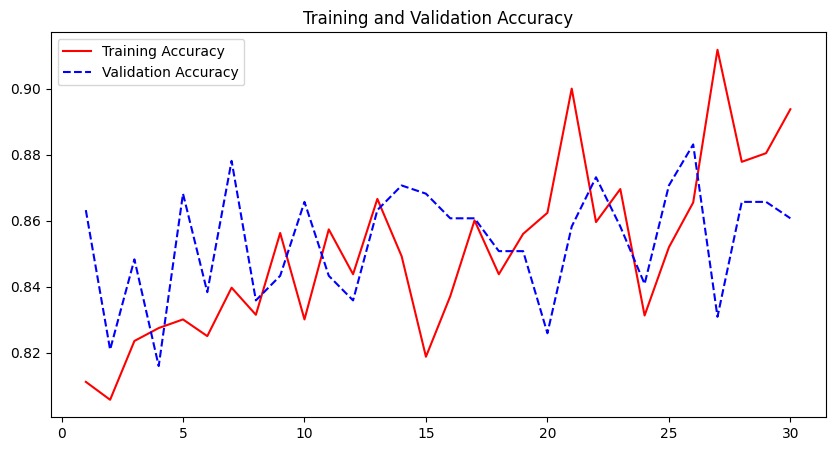

In [80]:
#plotting the results of loss and accuracy
plt.figure(figsize=(10, 5))
# epochs = range(1, len(history_4.history['accuracy']) + 1) # Update epochs based on the new history
# OR
#Since training was performed for 30 epochs
epochs = range(1, 31)
plt.plot(epochs, history_4.history['accuracy'], color="red", label="Training Accuracy")
plt.plot(epochs, history_4.history['val_accuracy'], color="blue", linestyle="dashed", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

In [81]:
# Evaluating the model
test_loss, test_acc = model_4.evaluate(test_generator)
print(f'Test Accuracy for {size} samples: {test_acc * 100:.2f}%')

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 365s 11s/step - accuracy: 0.8982 - loss: 0.2377
Test Accuracy for 750 samples: 89.90%


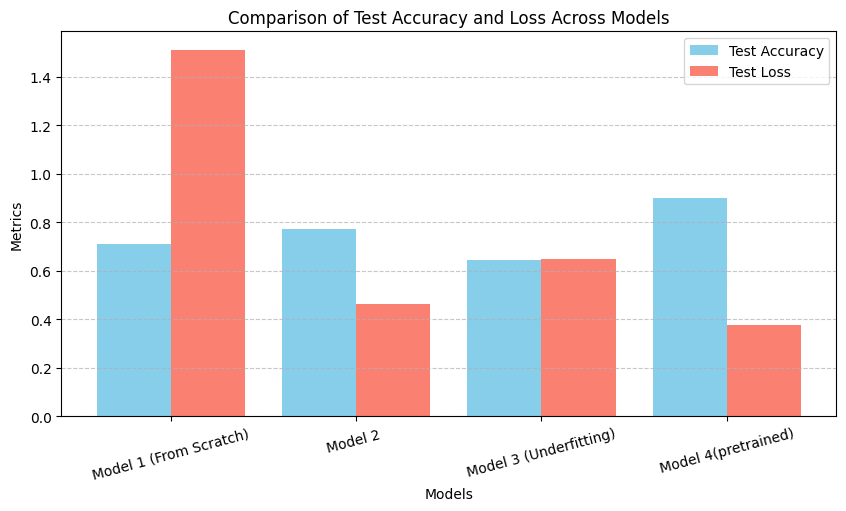

In [82]:
#compare all models by plotting
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ["Model 1 (From Scratch)", "Model 2 ", "Model 3 (Underfitting)", "Model 4(pretrained)"]

# Test accuracy and loss values respective to the models
test_accuracy = [0.710, 0.774, 0.644, 0.899]
test_loss = [1.5109, 0.464, 0.6465, 0.375]

# Set bar width
bar_width = 0.4
x = np.arange(len(models))

# Plotting test accuracy
plt.figure(figsize=(10, 5))
plt.bar(x - bar_width/2, test_accuracy, bar_width, label="Test Accuracy", color='skyblue')
plt.bar(x + bar_width/2, test_loss, bar_width, label="Test Loss", color='salmon')

# Formatting
plt.xlabel("Models")
plt.ylabel("Metrics")
plt.title("Comparison of Test Accuracy and Loss Across Models")
plt.xticks(x, models, rotation=15)
plt.legend()
plt.grid(axis='y', linestyle="--", alpha=0.7)

# Show plot
plt.show()
